# OLS analysis of imbalanced DOEs
> Ron S. Kenett, Chris Gotwalt, Laura Freeman, Peter Gedeck and Xinwei Deng


In [1]:
import common
import metrics

In [2]:
import itertools
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tqdm
import pickle


# Set random seed for reproducibility
In order to reproduce the results from the publication, the random seeds must be set to 123.

In [3]:
random.seed(123)
np.random.seed(123)

# Prepare dataset

In [4]:
# s, v0, k, t0 are mapped to x1, x2, x3, x4
n_replicate = 5
n_bootstrap = 1000
approach = 'single' # 
approach = 'individual'

full_data = common.preparePistonDataset(include_t0=False, n_replicate=n_replicate)
cases = common.prepareCases(3000, full_data['group'].max(), n_replicate=n_replicate)


In [5]:
list(full_data.groupby('group'))[0][1].sample(n=2)


,milliseconds,group,x1,x2,x3
2,60.693861,1,-1.0,-1.0,-1.0
3,52.717363,1,-1.0,-1.0,-1.0


In [6]:
def reduce_data(full_data, case):
    return pd.concat([group.sample(n=int(nc)) for (_, group), nc in zip(full_data.groupby('group'), case)])

reduce_data(full_data, cases[2999])

,milliseconds,group,x1,x2,x3
1,69.302551,1,-1.0,-1.0,-1.0
0,54.543605,1,-1.0,-1.0,-1.0
2,60.693861,1,-1.0,-1.0,-1.0
4,56.486824,1,-1.0,-1.0,-1.0
3,52.717363,1,-1.0,-1.0,-1.0
...,...,...,...,...,...
107,58.386572,22,0.0,0.0,0.0
106,69.223330,22,0.0,0.0,0.0
108,54.104635,22,0.0,0.0,0.0
105,60.629796,22,0.0,0.0,0.0


# Build a variety of models using main effects and interactions

In [7]:
main_terms_significant = 'x1 + x2 + x3'
interaction_terms = 'x1:x2 + x1:x3 + x2:x3'
quadratic_terms = 'I(x1**2) + I(x2**2) + I(x3**2)'
formula_full = f'milliseconds ~ {main_terms_significant} + {interaction_terms} + {quadratic_terms}'
group = ['x1', 'x2', 'x3']

# Bootstrap analysis

In [8]:
from numpy import append


def olsAnalysis(data, formula):
    model = common.buildModel(data, formula)
    return {'coef': model.params, 'std': model.bse}

methods = {
    'OLS': (olsAnalysis, {}),
}

def compareMethods(data, nrepeats):
    results = {}
    for key, (method, additional_kwargs) in methods.items():
        results.update({
            f'{key}_full': method(data, formula_full),
        })
    return results

def append_results(results, key, L1_metric, std_results, coef_results):
    r = results['std']
    r['metric'] = L1_metric
    r['method'] = key
    std_results.append(r)
    r = results['coef']
    r['metric'] = L1_metric
    r['method'] = key
    coef_results.append(r)

std_results = []
coef_results = []
for seed, case in enumerate(tqdm.tqdm(cases)):
    L1_metric = metrics.L1_distance(case)
    if approach == 'individual':
        full_data = common.preparePistonDataset(include_t0=False, n_replicate=n_replicate, seed=seed)
    result = olsAnalysis(full_data, formula_full)
    append_results(result, 'OLS_noimbalance', L1_metric, std_results, coef_results)
    data = reduce_data(full_data, case)
    for key, result in compareMethods(data, n_bootstrap).items():
        append_results(result, key, L1_metric, std_results, coef_results)
std_results = pd.DataFrame(std_results)
coef_results = pd.DataFrame(coef_results)
    

100%|██████████| 3000/3000 [00:33<00:00, 88.51it/s]


In [9]:
std_results


,Intercept,x1,x2,x3,x1:x2,x1:x3,x2:x3,I(x1 ** 2),I(x2 ** 2),I(x3 ** 2),metric,method
0,1.271617,0.973969,0.973969,0.973969,1.272552,1.272552,1.272552,0.914466,0.914466,0.914466,3.409091,OLS_noimbalance
1,1.760161,1.486637,1.646490,1.646490,2.117924,2.117924,2.117924,1.259940,1.554379,1.554379,3.409091,OLS_full
2,1.320615,1.011498,1.011498,1.011498,1.321586,1.321586,1.321586,0.949702,0.949702,0.949702,3.500000,OLS_noimbalance
3,2.100571,1.423250,1.484892,1.484892,1.838959,1.838959,1.777245,1.557260,1.557260,1.557260,3.500000,OLS_full
4,1.395251,1.068664,1.068664,1.068664,1.396277,1.396277,1.396277,1.003376,1.003376,1.003376,3.318182,OLS_noimbalance
...,...,...,...,...,...,...,...,...,...,...,...,...
5995,1.208170,0.925374,0.925374,0.925374,1.209059,1.209059,1.209059,0.868839,0.868839,0.868839,0.000000,OLS_full
5996,1.292158,0.989702,0.989702,0.989702,1.293109,1.293109,1.293109,0.929238,0.929238,0.929238,0.000000,OLS_noimbalance
5997,1.292158,0.989702,0.989702,0.989702,1.293109,1.293109,1.293109,0.929238,0.929238,0.929238,0.000000,OLS_full
5998,1.444247,1.106192,1.106192,1.106192,1.445310,1.445310,1.445310,1.038611,1.038611,1.038611,0.000000,OLS_noimbalance


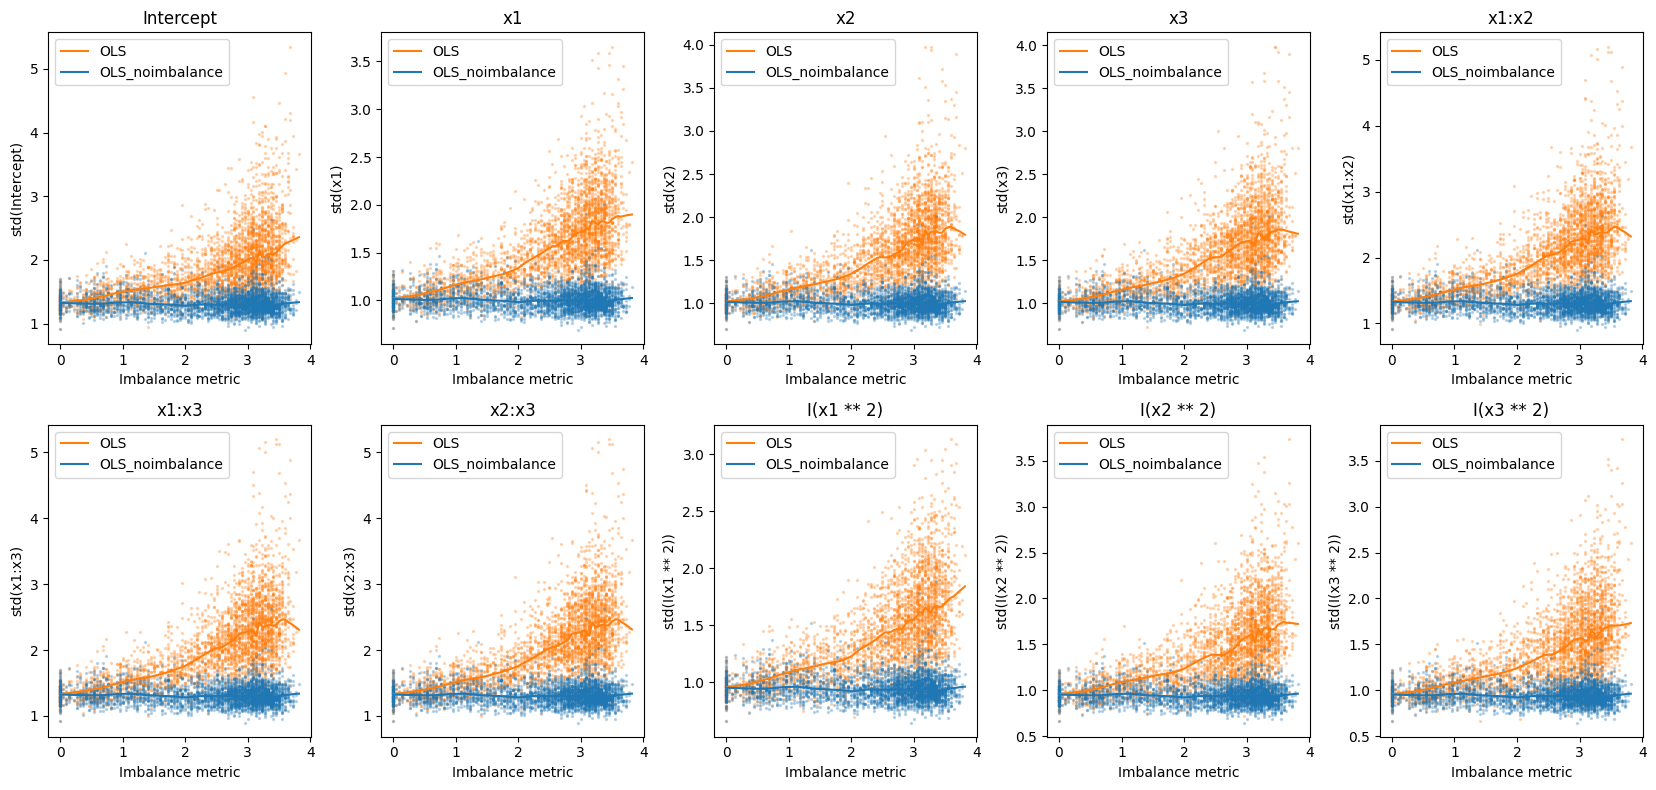

In [10]:
def plot_results(results, term, method, color, ax, size, alpha):
    subset = results[results['method'] == method]
    subset.plot.scatter(x='metric', y=term, c=color, ax=ax, alpha=alpha, s=size)
    common.make_lowess(subset['metric'], subset[term]).plot(x='x', y='y', ax=ax, color=color, label=method.replace('_full', ''))


results = std_results

terms = ['Intercept', 'x1', 'x2', 'x3', 'x1:x2', 'x1:x3', 'x2:x3', 'I(x1 ** 2)', 'I(x2 ** 2)', 'I(x3 ** 2)']
ncols=5; nrows=2
fig, axes = plt.subplots(ncols=5, nrows=2, figsize=[20 * ncols / 6, 4 * nrows])
axes = itertools.chain(*axes)
size=2; alpha=0.25
for ax, term in zip(axes, terms):
    plot_results(std_results, term, 'OLS_full', 'C1', ax, size, alpha)
    # plot_results(std_results, term, 'wBA_full', 'C2', ax, size, alpha)
    plot_results(std_results, term, 'OLS_noimbalance', 'C0', ax, size, alpha)
    ax.set_title(term)
    ax.set_ylabel(f'std({term})')
    ax.set_xlabel('Imbalance metric')
plt.tight_layout()

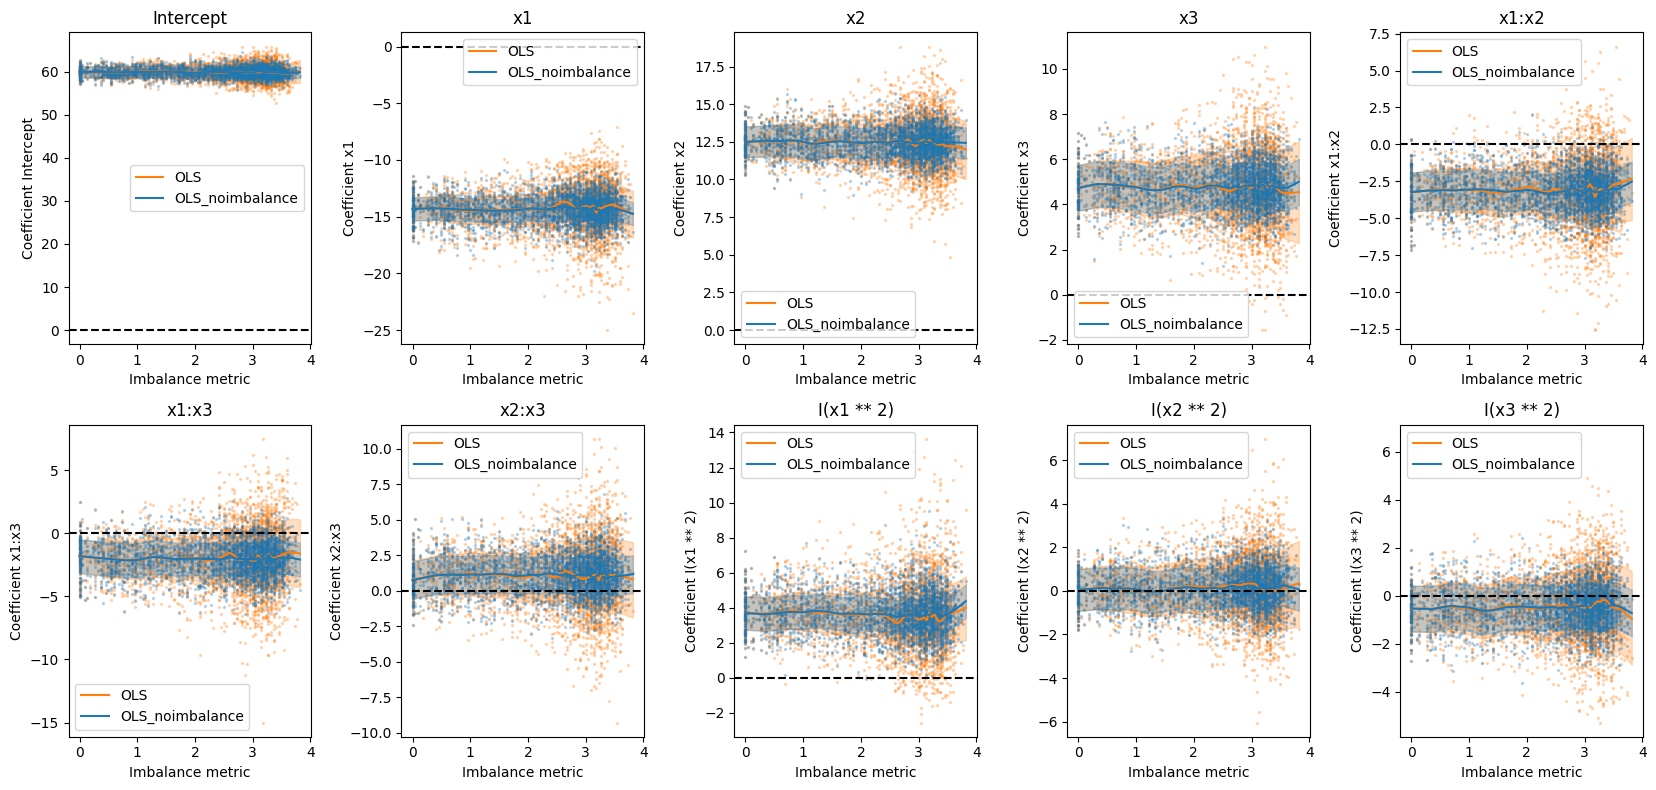

In [ ]:
def plot_results(coef_results, std_results, term, method, color, ax, size, alpha):
    coef_subset = coef_results[coef_results['method'] == method]
    std_subset = std_results[std_results['method'] == method]
    coeff_lowess = common.make_lowess(coef_subset['metric'], coef_subset[term])
    coeff_upper_lowess = common.make_lowess(coef_subset['metric'], coef_subset[term] + std_subset[term])
    coeff_lower_lowess = common.make_lowess(coef_subset['metric'], coef_subset[term] - std_subset[term])
    ax.fill_between(coeff_lowess['x'], coeff_lower_lowess['y'], coeff_upper_lowess['y'], color=color, alpha=alpha)
    coeff_lowess.plot(x='x', y='y', ax=ax, color=color, label=method.replace('_full', ''))
    

terms = ['Intercept', 'x1', 'x2', 'x3', 'x1:x2', 'x1:x3', 'x2:x3', 'I(x1 ** 2)', 'I(x2 ** 2)', 'I(x3 ** 2)']
ncols=5; nrows=2
fig, axes = plt.subplots(ncols=5, nrows=2, figsize=[20 * ncols / 6, 4 * nrows])
axes = itertools.chain(*axes)
size=2; alpha=0.25
for ax, term in zip(axes, terms):
    plot_results(coef_results, std_results, term, 'OLS_full', 'C1', ax, size, 0.25)
    plot_results(coef_results, std_results, term, 'OLS_noimbalance', 'C0', ax, size, 0.25)
    ax.set_title(term)
    ax.set_ylabel(f'Coefficient {term}')
    ax.set_xlabel('Imbalance metric')
    ax.axhline(0, color='black', linestyle='--')
plt.tight_layout()

In [12]:
open(f'results_individual_{n_replicate}_ols.pkl', 'wb').write(pickle.dumps({'std_results': std_results, 'coef_results': coef_results}))


1116643

- Overlay OLS results
- Repeat with max replicates 4, 3, 2